# Research Objective

This notebook performs a data-centric exploratory analysis for evaluating feature reliability in machine learning pipelines.

The analysis focuses on:
- feature stability
- feature drift possibility
- feature behavior analysis
- feature reliability indicators
- outlier sensitivity
- distribution consistency

The goal is to identify potentially unreliable features before model training.

# Future Reliability Metrics

The next phase of the research framework will focus on quantitative feature reliability evaluation using:

- Feature Stability Score
- Feature Drift Score
- Feature Importance Consistency Score

These metrics will help establish a unified data-centric framework for analyzing feature behavior and reliability in machine learning pipelines.

# Research Flow Diagram


```text
Raw Data
   ↓
Data Quality Analysis
   ↓
Feature Behavior Analysis
   ↓
Feature Reliability Indicators
   ↓
Model Evaluation
   ↓
Reliability Assessment Framework

# SECTION 1 — Import Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

# Plot settings

plt.style.use('default')

sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)


# SECTION 2 — Load Dataset

# Dataset Role in Research

| Dataset | Research Purpose |
|----------|------------------|
| Loan Prediction | Feature Importance Consistency |
| House Price | Feature Stability Analysis |
| Credit Card Fraud | Feature Drift Analysis |

In [63]:
loan_df = pd.read_csv('/kaggle/input/datasets/kishanbouri/raw-data/loan_data_set.csv')

house_df = pd.read_csv('/kaggle/input/datasets/kishanbouri/raw-data/data.csv')

credit_df = pd.read_csv('/kaggle/input/datasets/kishanbouri/raw-data/creditcard.csv')

# SECTION 3 — Basic Dataset Understanding

**A. Loan Dataset Overview**

In [64]:
print("Loan Dataset Shape:", loan_df.shape)

loan_df.head()

Loan Dataset Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [65]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [66]:
loan_df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


Research Observation:
- The dataset contains both categorical and numerical features.
- Some features may contain missing values.
- Income-related features may show instability due to skewed distributions.
- This dataset is useful for analyzing feature importance consistency.

**B. House Price Dataset Overview**

In [67]:
print("House Dataset Shape:", house_df.shape)

house_df.head()

House Dataset Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [68]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [69]:
house_df.describe(include='all')

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
count,4600,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600,4600,4600,4600
unique,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4525,44,77,1
top,2014-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2520 Mulberry Walk NE,Seattle,WA 98103,USA
freq,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1573,148,4600
mean,NaN,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,NaN,NaN,NaN,NaN
std,NaN,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,NaN,NaN,NaN,NaN
min,NaN,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,NaN,NaN,NaN,NaN
75%,NaN,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,NaN,NaN,NaN,NaN


Research Observation:
- The dataset contains highly continuous numerical features.
- Several features may have large variance and skewness.
- Useful for feature stability analysis.

 **C. Credit Card Dataset Overview**

In [70]:
print("Credit Card Dataset Shape:", credit_df.shape)

credit_df.head()

Credit Card Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [71]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [72]:
credit_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Research Observation:
- Dataset is highly imbalanced.
- Transaction-related features may show drift behavior over time.
- Suitable for feature drift analysis and reliability monitoring.

# SECTION 3.1 — Missing Value Analysis

In [73]:
loan_missing = loan_df.isnull().sum()

loan_missing[loan_missing > 0]

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

In [74]:
house_missing = house_df.isnull().sum()

house_missing[house_missing > 0]

Series([], dtype: int64)

In [75]:
credit_missing = credit_df.isnull().sum()

credit_missing[credit_missing > 0]

Series([], dtype: int64)

# Data Quality Summary

The following observations summarize major data quality and feature reliability concerns identified during exploratory analysis.

| Dataset | Missing Values | High Skew Features | Outlier Presence | Reliability Concern |
|----------|----------------|-------------------|------------------|---------------------|
| Loan | Moderate | ApplicantIncome | Medium | Stability Risk |
| House | Low | LotArea | High | Drift Sensitive |
| Credit | None | Amount | Very High | Drift-Prone Feature Behavior |

These observations indicate that feature reliability analysis is necessary before model training and long-term deployment evaluation.

# SECTION 3.2 — Duplicate Check

In [76]:
loan_duplicates = loan_df.duplicated().sum()

print("Loan Dataset Duplicate Rows:", loan_duplicates)

Loan Dataset Duplicate Rows: 0


In [77]:
house_duplicates = house_df.duplicated().sum()

print("House Dataset Duplicate Rows:", house_duplicates)

House Dataset Duplicate Rows: 0


In [78]:
credit_duplicates = credit_df.duplicated().sum()

print("Credit Dataset Duplicate Rows:", credit_duplicates)

Credit Dataset Duplicate Rows: 1081


Research Interpretation:
The Credit Card dataset contains 1081 duplicate records. Duplicate transactions may artificially reinforce specific feature patterns, bias model learning, and distort feature importance measurements. In feature reliability analysis, duplicate samples can reduce the trustworthiness of statistical behavior and affect drift sensitivity evaluation.

In [79]:
credit_df = credit_df.drop_duplicates()

print("New Shape After Removing Duplicates:", credit_df.shape)


New Shape After Removing Duplicates: (283726, 31)


Research Action:
Duplicate records were removed to ensure more reliable feature behavior analysis and unbiased model evaluation.

# SECTION 4 — Feature Type Categorization

In [80]:
loan_num_cols = loan_df.select_dtypes(include=np.number).columns.tolist()

loan_cat_cols = loan_df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(loan_num_cols)

print("\nCategorical Features:")
print(loan_cat_cols)

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [81]:
house_num_cols = house_df.select_dtypes(include=np.number).columns.tolist()

house_cat_cols = house_df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(house_num_cols)

print("\nCategorical Features:")
print(house_cat_cols)

Numerical Features:
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']

Categorical Features:
['date', 'street', 'city', 'statezip', 'country']


In [82]:
credit_num_cols = credit_df.select_dtypes(include=np.number).columns.tolist()

credit_cat_cols = credit_df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(credit_num_cols)

print("\nCategorical Features:")
print(credit_cat_cols)

Numerical Features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Categorical Features:
[]


# SECTION 5 — Distribution Analysis

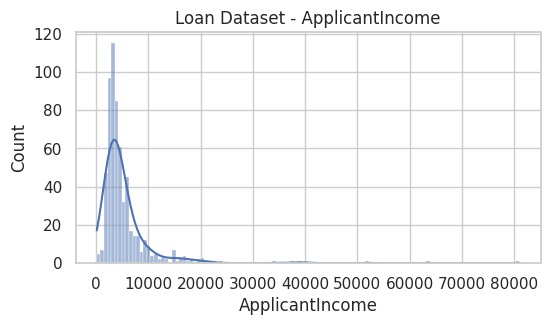

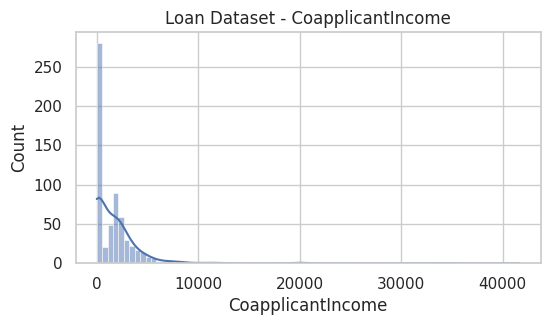

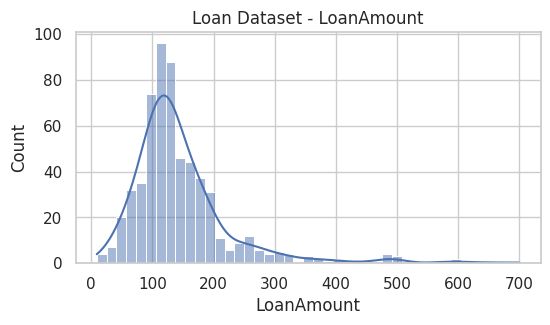

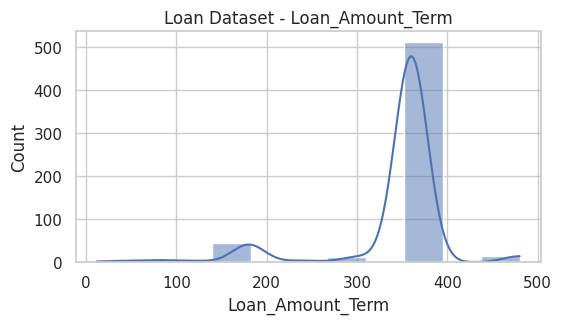

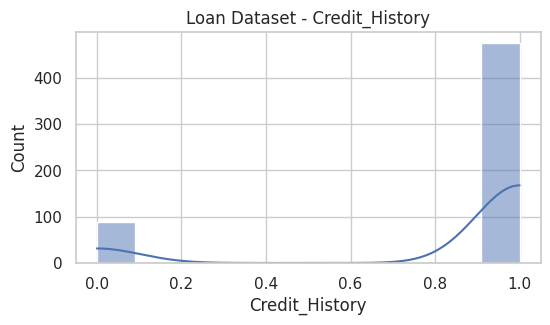

In [83]:
for col in loan_num_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.histplot(loan_df[col].dropna(), kde=True)
    
    plt.title(f'Loan Dataset - {col}')
    
    plt.show()

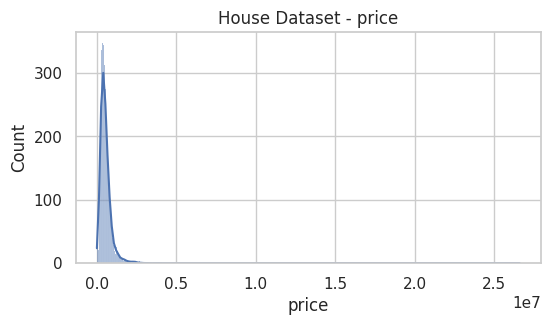

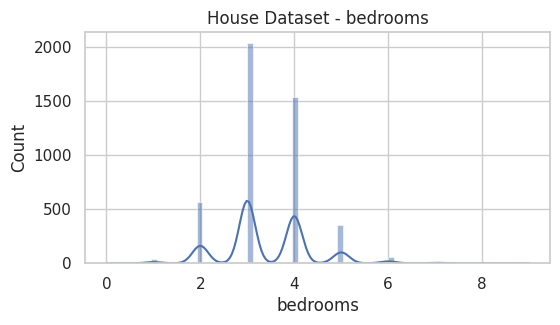

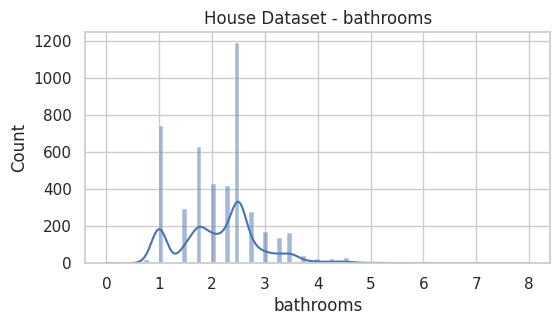

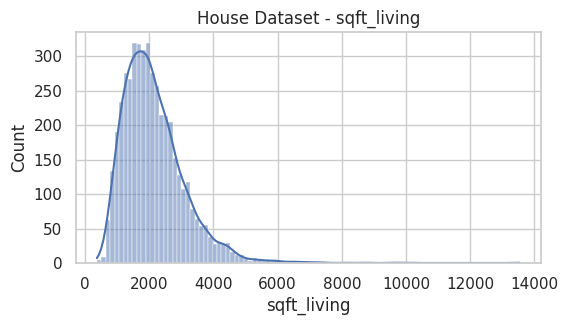

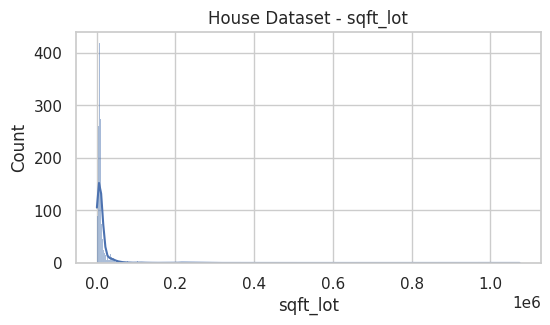

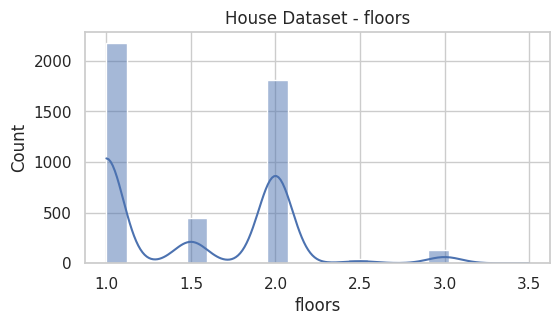

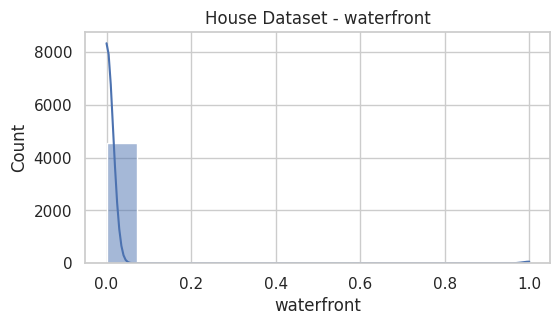

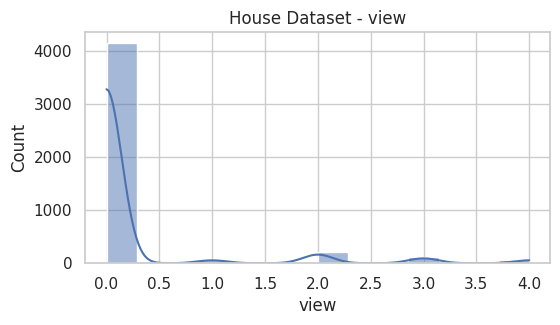

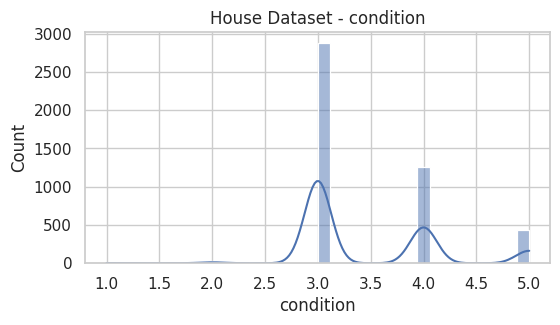

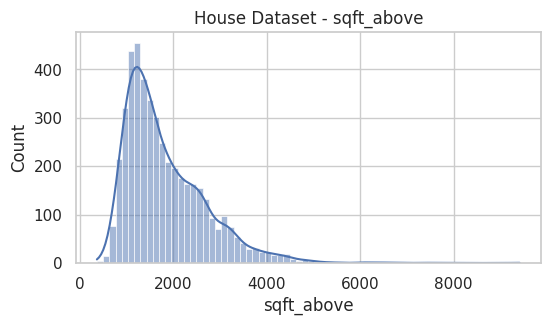

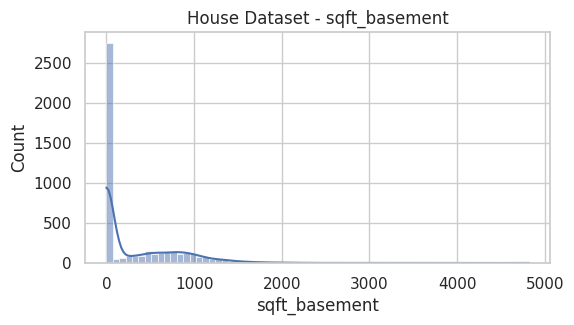

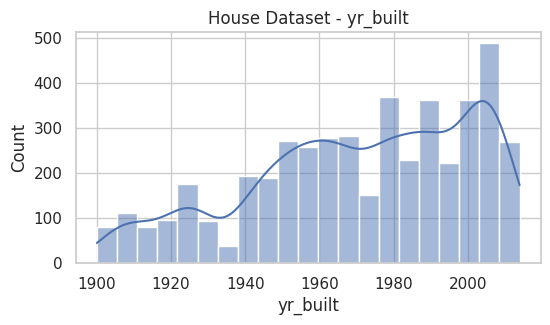

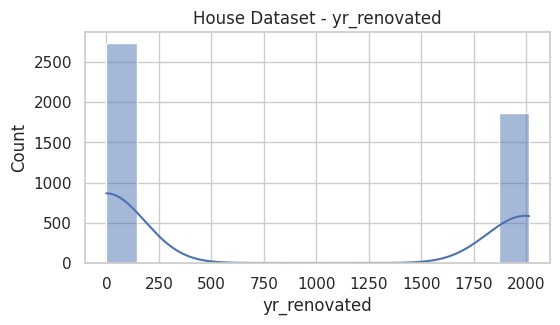

In [84]:
for col in house_num_cols[:15]:
    
    plt.figure(figsize=(6,3))
    
    sns.histplot(house_df[col].dropna(), kde=True)
    
    plt.title(f'House Dataset - {col}')
    
    plt.show()

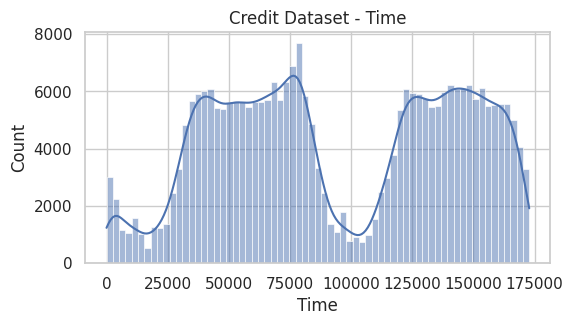

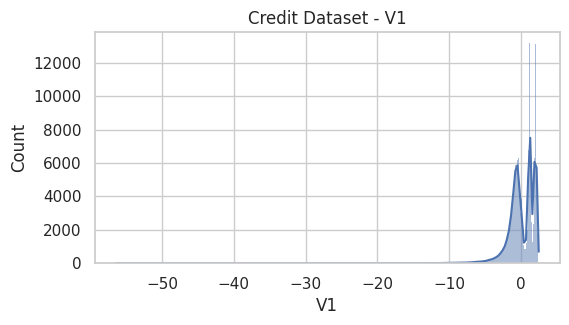

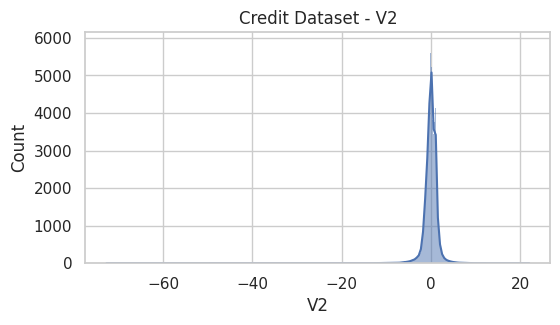

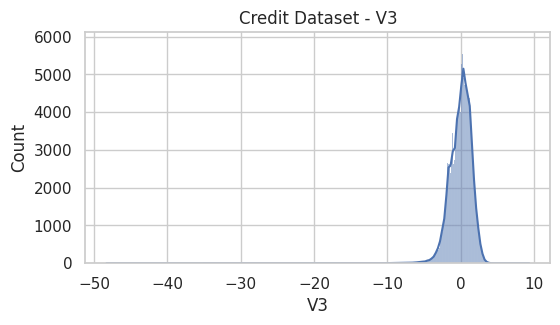

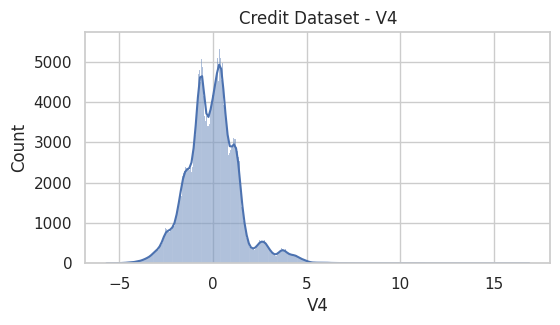

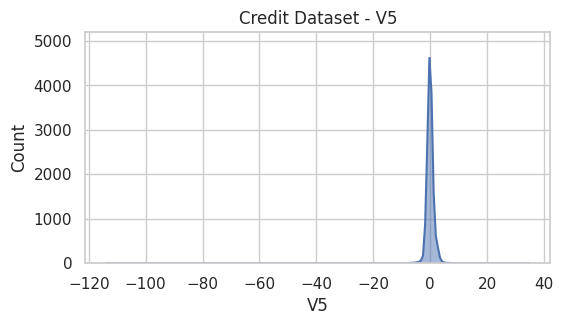

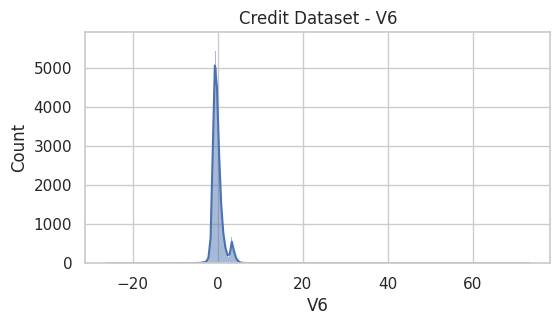

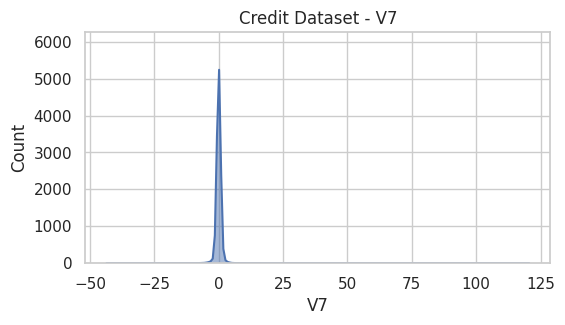

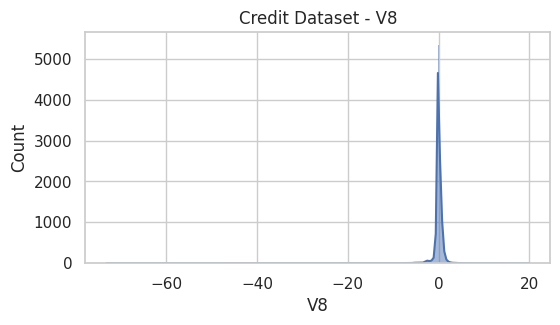

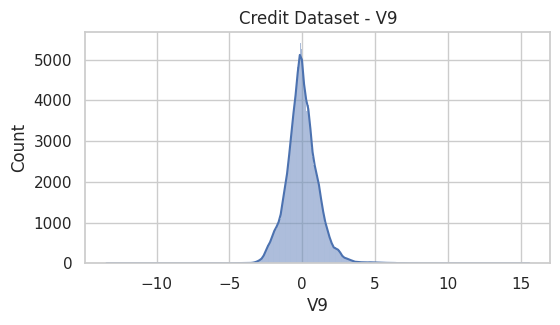

In [85]:
for col in credit_num_cols[:10]:
    
    plt.figure(figsize=(6,3))
    
    sns.histplot(credit_df[col].dropna(), kde=True)
    
    plt.title(f'Credit Dataset - {col}')
    
    plt.show()

Research Insight:
Features such as applicant income exhibit strong positive skewness and several extreme outliers. Such statistical behavior may reduce feature stability and increase sensitivity to distributional drift during model deployment.

Research Interpretation:
Feature distributions help identify:
- unstable features
- skewed behavior
- outlier sensitivity
- potential drift-prone attributes

Features with highly irregular distributions may reduce long-term model reliability.


**# Potential Drift-Sensitive Features**


| Feature            | Reason                       |
| ------------------ | ---------------------------- |
| Transaction Amount | Dynamic transaction behavior |
| ApplicantIncome    | Economic variability         |
| LotArea            | High variance distribution   |


These features may exhibit changing statistical behavior across time, environments, or data collection conditions, making them important candidates for future drift analysis.

# SECTION 6 — Skewness Analysis

In [86]:
loan_skew = loan_df[loan_num_cols].skew().sort_values(ascending=False)

loan_skew

CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.677552
Credit_History      -1.882361
Loan_Amount_Term    -2.362414
dtype: float64

In [87]:
loan_df[loan_num_cols].std().sort_values(ascending=False)

ApplicantIncome      6109.041673
CoapplicantIncome    2926.248369
LoanAmount             85.587325
Loan_Amount_Term       65.120410
Credit_History          0.364878
dtype: float64

In [88]:
house_skew = house_df[house_num_cols].skew().sort_values(ascending=False)

house_skew

price            24.790933
waterfront       11.682901
sqft_lot         11.307139
view              3.341586
sqft_living       1.723513
sqft_basement     1.642732
sqft_above        1.494211
condition         0.959068
bathrooms         0.616033
floors            0.551441
bedrooms          0.456447
yr_renovated      0.385919
yr_built         -0.502155
dtype: float64

In [89]:
credit_skew = credit_df[credit_num_cols].skew().sort_values(ascending=False)

credit_skew

Class     24.430545
Amount    16.978803
V28       11.555115
V7         2.890271
V21        2.820033
V6         1.829880
V10        1.252967
V4         0.671504
V26        0.580292
V9         0.537663
V11        0.344074
V19        0.108312
V13        0.064293
Time      -0.035581
V22       -0.182330
V18       -0.248661
V15       -0.309659
V25       -0.415744
V24       -0.552129
V27       -0.753804
V16       -1.051161
V14       -1.918804
V20       -2.043121
V3        -2.151984
V12       -2.199008
V5        -2.414079
V1        -3.273271
V17       -3.690497
V2        -4.695162
V23       -5.867221
V8        -8.310970
dtype: float64

Research Interpretation:
Highly skewed features may indicate instability and sensitivity to distributional changes. Such features can negatively affect feature reliability over time.

# SECTION 7 — Correlation Analysis

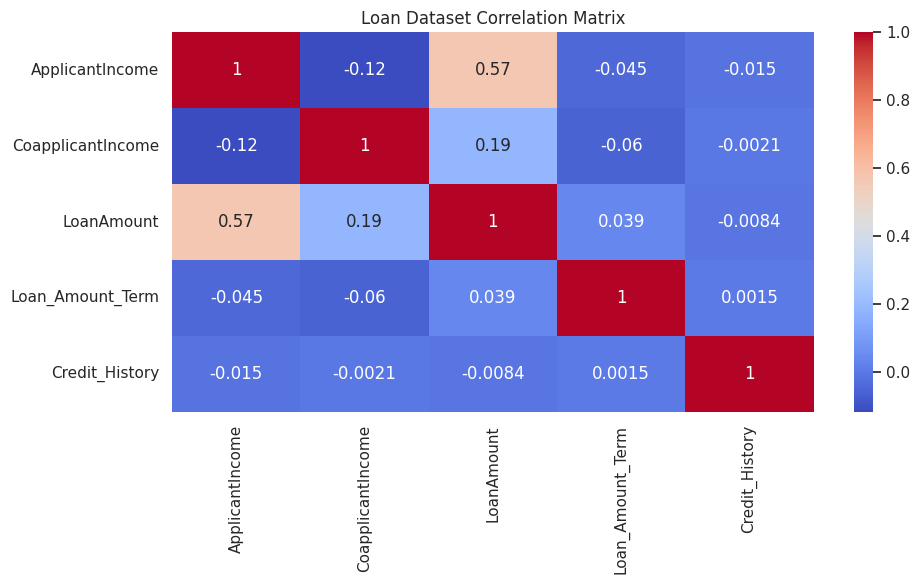

In [90]:
plt.figure(figsize=(10,6))

sns. heatmap(
    loan_df[loan_num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Loan Dataset Correlation Matrix")
plt.tight_layout()
plt.show()


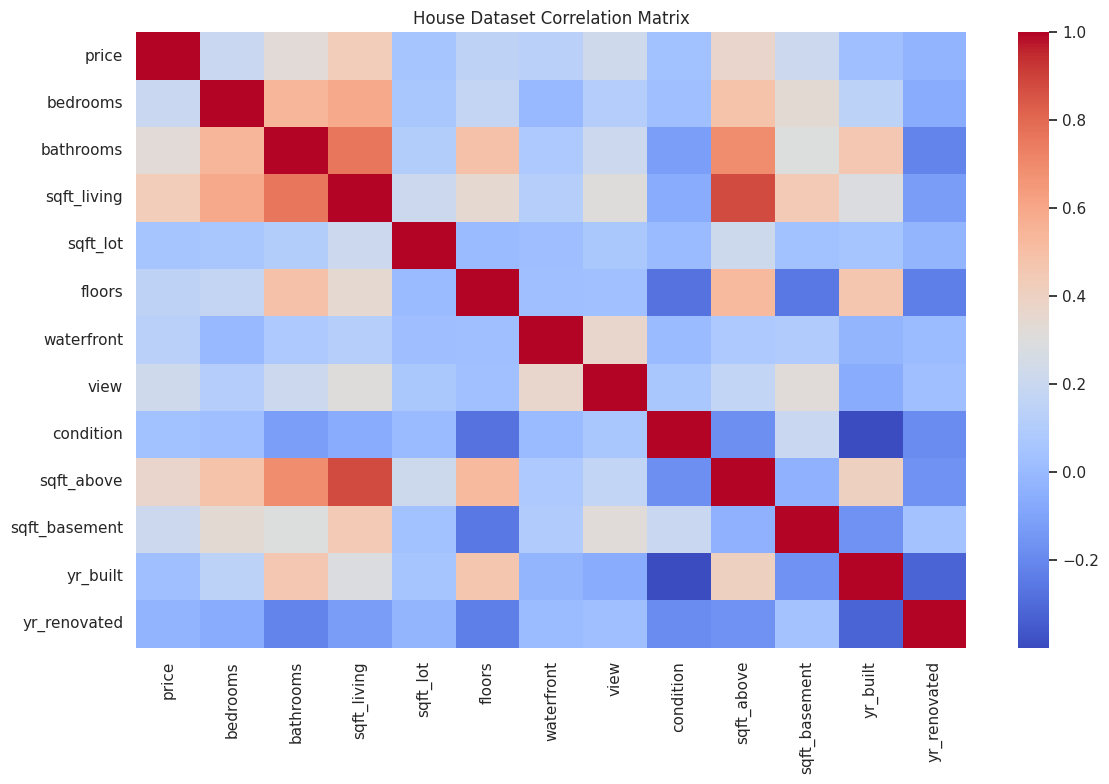

In [91]:
plt.figure(figsize=(12,8))

sns. heatmap(
    house_df[house_num_cols].corr(),
    cmap='coolwarm'
)

plt.title("House Dataset Correlation Matrix")
plt.tight_layout()
plt.show()

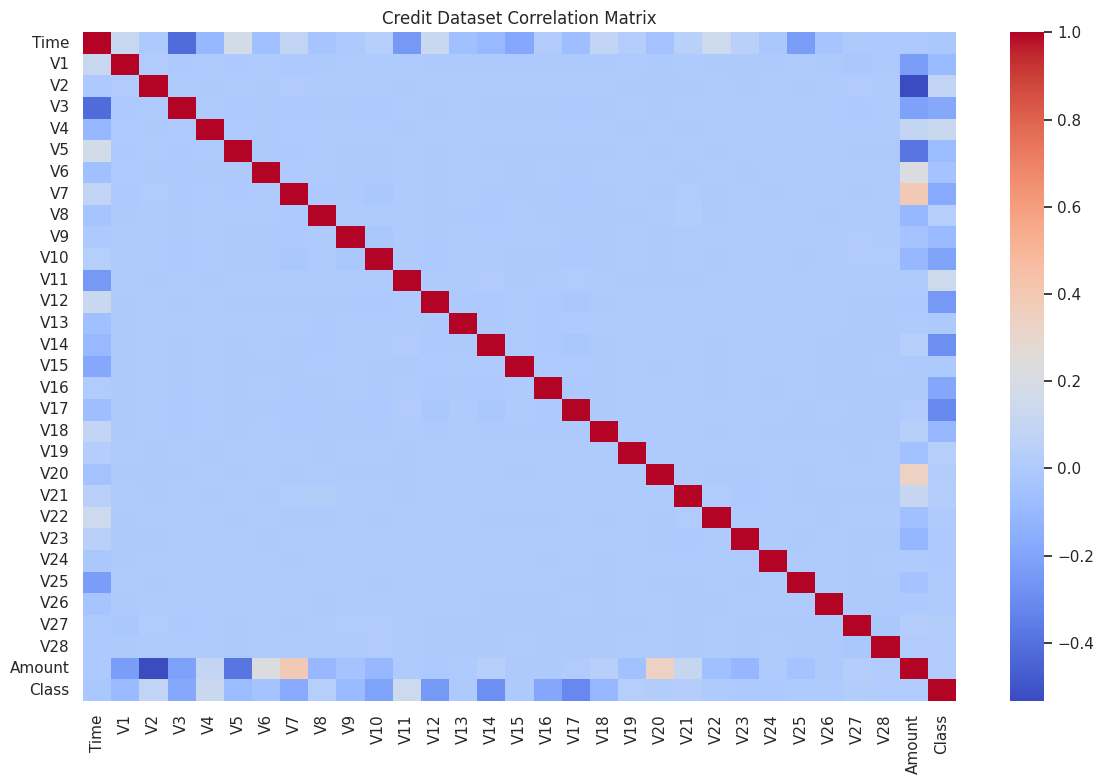

In [92]:
plt.figure(figsize=(12,8))

sns. heatmap(
    credit_df[credit_num_cols].corr(),
    cmap='coolwarm'
)

plt.title("Credit Dataset Correlation Matrix")
plt.tight_layout()
plt.show()

# SECTION 8 — Outlier Detection

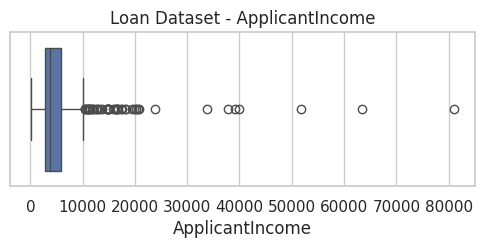

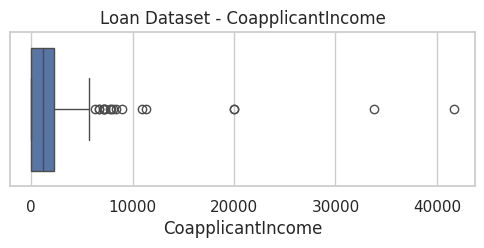

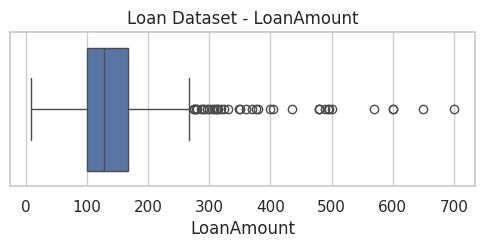

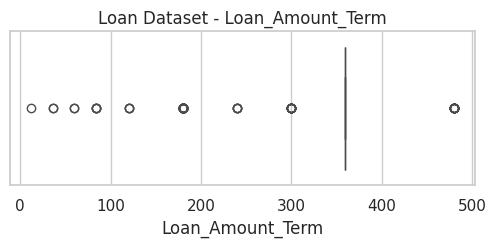

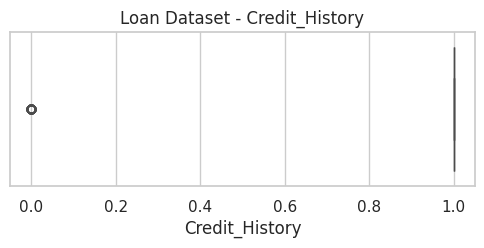

In [93]:
for col in loan_num_cols:
    
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=loan_df[col])
    
    plt.title(f'Loan Dataset - {col}')
    
    plt.show()

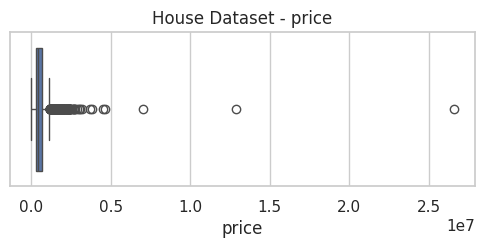

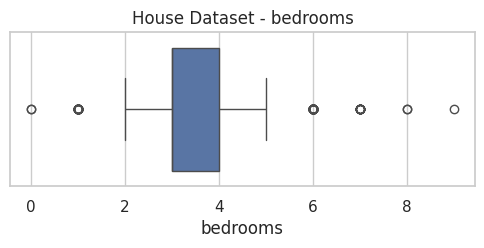

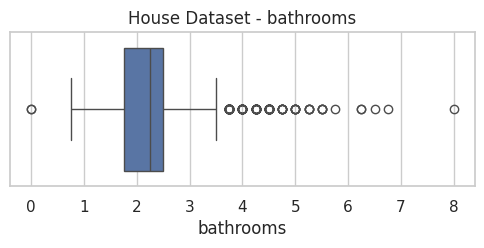

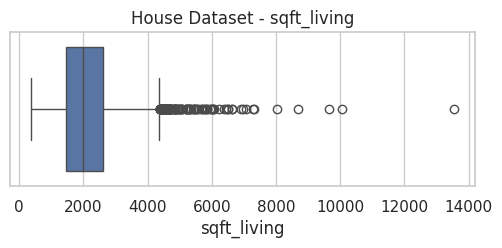

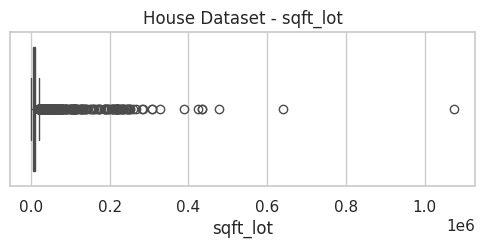

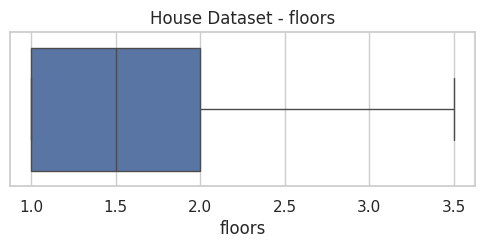

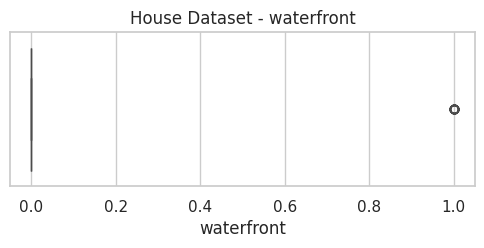

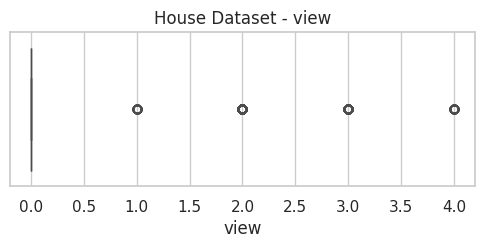

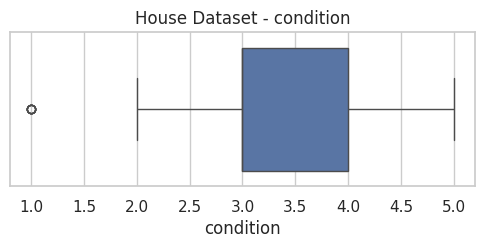

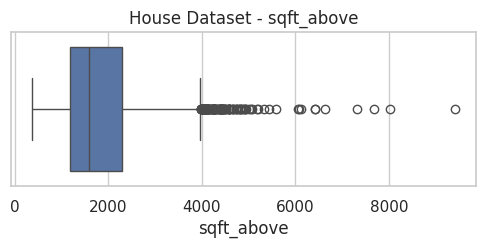

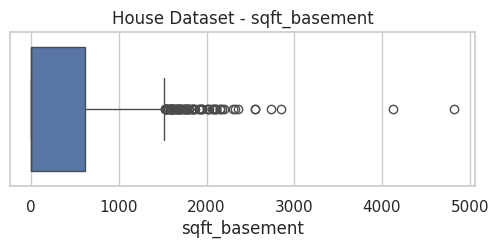

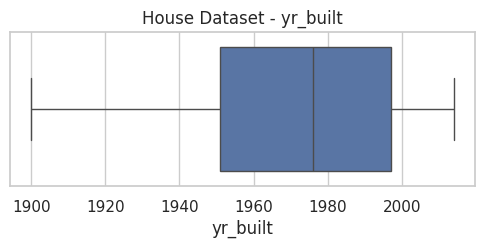

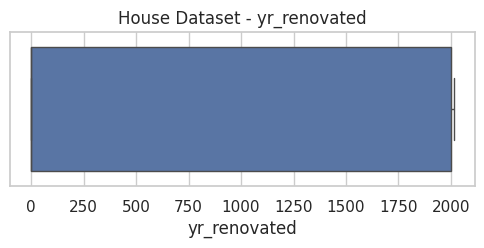

In [94]:
for col in house_num_cols[:15]:
    
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=house_df[col])
    
    plt.title(f'House Dataset - {col}')
    
    plt.show()

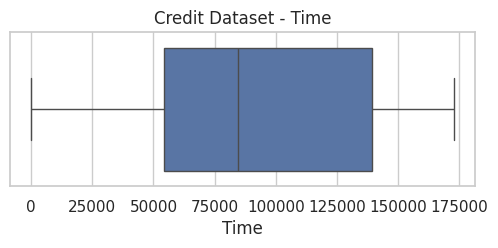

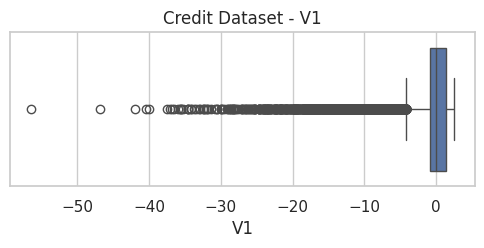

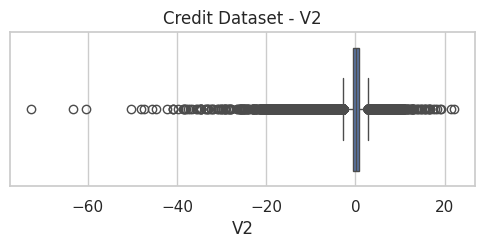

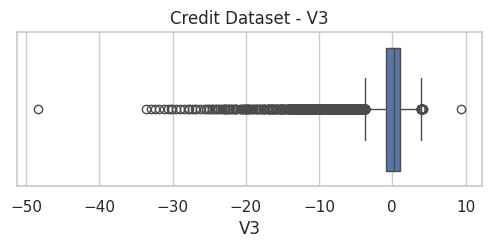

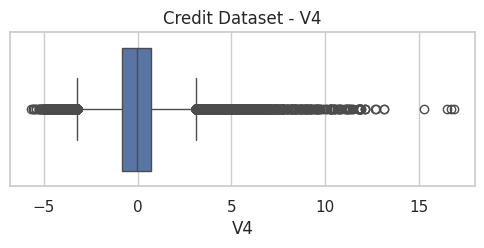

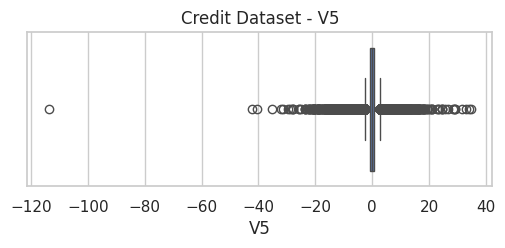

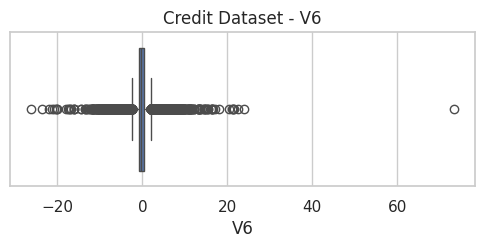

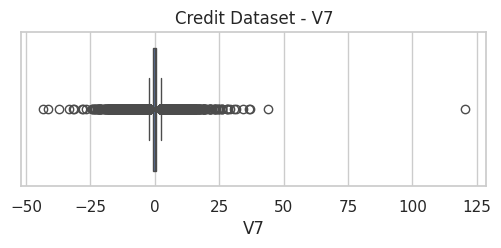

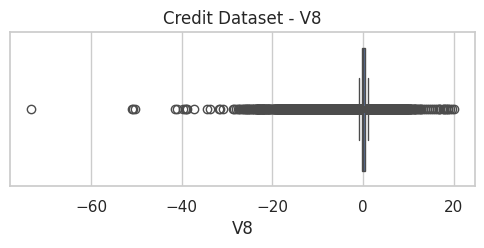

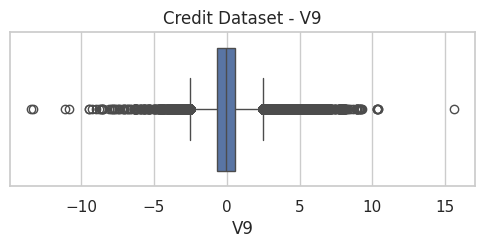

In [95]:
for col in credit_num_cols[:10]:
    
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=credit_df[col])
    
    plt.title(f'Credit Dataset - {col}')
    
    plt.show()

Research Interpretation:
Outliers may increase feature instability, affect model robustness, and amplify feature drift behavior during deployment.

# SECTION 9 — Class Imbalance Analysis

**Credit Dataset Class Distribution**

In [96]:
credit_df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [97]:
credit_df['Class'].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

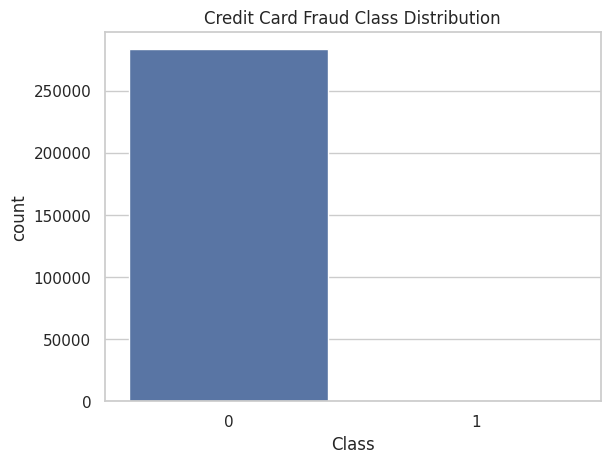

In [98]:
sns.countplot(x='Class', data=credit_df)

plt.title("Credit Card Fraud Class Distribution")

plt.show()

Research Interpretation:
Severe class imbalance can influence feature importance consistency and increase model sensitivity to unstable feature behavior.

# Initial Feature Reliability Notes

| Dataset | Feature         | Observation      | Reliability Concern  |
| ------- | --------------- | ---------------- | -------------------- |
| Loan    | ApplicantIncome | Highly skewed    | Possible instability |
| Loan    | Credit_History  | Stable           | Reliable             |
| House   | LotArea         | Extreme variance | Drift sensitive      |
| Credit  | Amount          | Heavy outliers   | Unstable behavior    |



     | Credit | Time | Sequential transaction behavior | Potential drift candidate |


In [99]:
loan_df.to_csv('/kaggle/working/loan_cleaned.csv', index=False)

house_df.to_csv('/kaggle/working/house_cleaned.csv', index=False)

credit_df.to_csv('/kaggle/working/credit_cleaned.csv', index=False)

In [100]:
loan_cleaned = loan_df.copy()

# Conclusion

The exploratory analysis identified several feature reliability concerns including:

- skewed feature distributions
- outlier sensitivity
- duplicate transaction patterns
- potential instability
- possible feature drift behavior

The analysis demonstrates that data quality and feature behavior play a significant role in machine learning reliability beyond traditional model accuracy evaluation.

These findings support the need for a systematic data-centric framework for feature reliability analysis in machine learning pipelines.